<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula05b%20-%20Single%20Hidden%20Layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

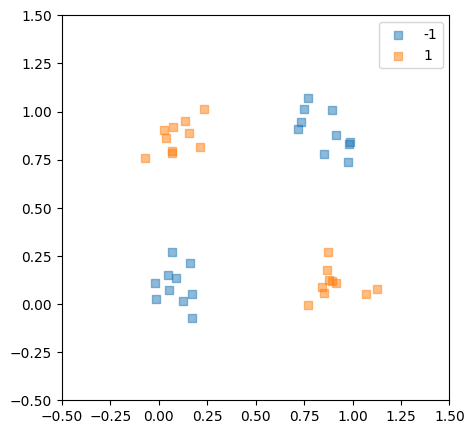

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

def createLogicalDataset(n=40, func= lambda a, b: bool(a) != bool(b)):
  X, y = make_blobs(n_samples=n,
                    centers=[[0.1,0.1], [0.9, 0.1], [0.1, 0.9], [0.9, 0.9]],
                    n_features=2,
                    cluster_std=0.1,
                    center_box=(0,1))
  y = np.array([func(a>0.5, b>0.5) for a, b in X], dtype=int)*2-1
  return X, y

def plotDataset(X, y, marker='s'):
  for i in sorted(list(set(y))):
    plt.scatter(X[y==i,0], X[y==i,1], label=f"{i}", alpha=0.5, marker=marker)
  plt.xlim(-0.5,1.5)
  plt.ylim(-0.5,1.5)
  plt.legend()

def plotHyperplan(vector, intercept, legend="hyperplan"):
    xs = np.array([0, 1])
    ys = -(vector[0] * xs + intercept) / vector[1]
    plt.plot(xs, ys, label=legend)
    plt.legend()

X, y = createLogicalDataset()
plt.figure(figsize=(5,5))
plotDataset(X, y)
plt.show()

Accuracy: 1.0
Weights: [[ 1.61168429]
 [-2.22000651]
 [-2.20070355]]


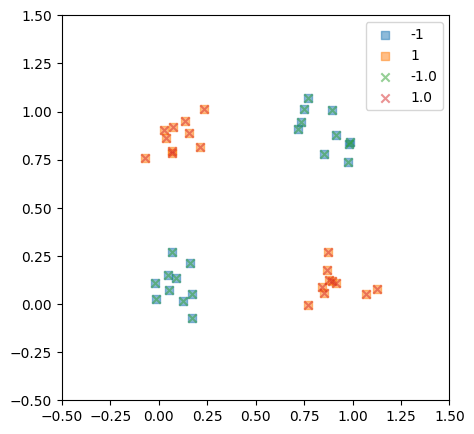

In [73]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.c_[np.ones(X.shape[0]), X]

class LastLayer(BaseEstimator, ClassifierMixin):
  def __init__(self, max_iter=100, learning_rate=0.01):
    self.max_iter = max_iter
    self.learning_rate = learning_rate
    self.n_hidden = 2
    self.activation = np.tanh

  def forward(self, X):
    self.Xb = include_bias(X)
    self.pH = self.Xb @ self.ihw
    self.H = self.activation(self.pH)
    self.Hb = include_bias(self.H)
    logits = self.Hb @ self.how
    return logits

  def backward(self, y, y_pred):
    error = y - y_pred
    delta = self.Hb.T @ error
    self.how += self.learning_rate * delta
    return self

  def fit(self, X, y):
    self.ihw = np.array([[0.5,-1,1],[0.5,1,-1]]).T
    if len(y.shape) == 1:
      y = y.reshape(-1,1)
    self.how = np.random.uniform(-1, 1, size=(self.ihw.shape[1]+1, y.shape[1]))
    for _ in range(self.max_iter):
      logits = self.forward(X)
      self.backward(y, logits)
    return self

  def predict(self, X):
    logits = self.forward(X)
    y_pred = np.sign(logits)
    return y_pred.reshape(-1)

model = LastLayer()
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.how}")
plt.figure(figsize=(5,5))
plotDataset(X, y)
plotDataset(X, y_pred, 'x')
plt.show()

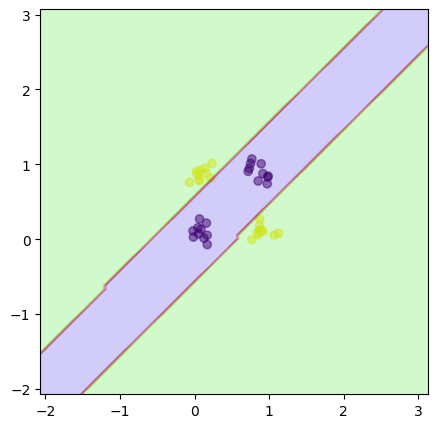

In [74]:
def defineAxes(X):
  offset = 2
  min1, max1 = X[:,0].min()-offset, X[:,0].max()+offset
  min2, max2 = X[:,1].min()-offset, X[:,1].max()+offset
  return [min1, max1, min2, max2]

def plotPredictions(model, X):
  axes = defineAxes(X)
  x0s = np.linspace(axes[0], axes[1], 100)
  x1s = np.linspace(axes[2], axes[3], 100)
  x0, x1 = np.meshgrid(x0s, x1s)
  X = np.c_[x0.ravel(), x1.ravel()]
  ypred = model.predict(X).reshape(x0.shape)
  plt.contourf(x0, x1, ypred, cmap=plt.cm.brg, alpha=0.2)

plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, alpha=0.5)
plotPredictions(model, X)
plt.show()

Accuracy: 1.0
Weights: [[-1.3958455 ]
 [ 2.1450919 ]
 [-1.88341367]]


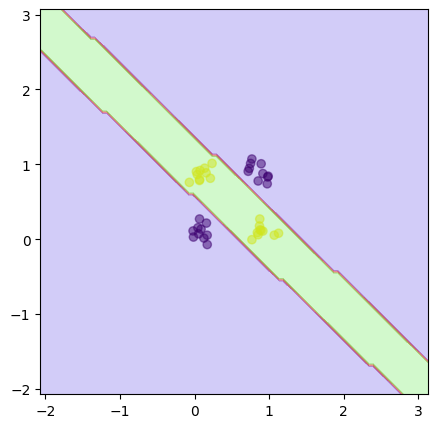

In [129]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.c_[np.ones(X.shape[0]), X]

class SingleHiddenLayer(BaseEstimator, ClassifierMixin):
  def __init__(self, n_hidden=2, max_iter=10000, learning_rate=0.005):
    self.max_iter = max_iter
    self.learning_rate = learning_rate
    self.n_hidden = n_hidden
    self.activation = np.tanh

  def forward(self, X):
    self.Xb = include_bias(X)
    self.pH = self.Xb @ self.ihw
    self.H = self.activation(self.pH)
    self.Hb = include_bias(self.H)
    logits = self.Hb @ self.how
    return logits

  def backward(self, y, y_pred):
    ho_delta = y - y_pred
    ho_grad = self.Hb.T @ ho_delta
    ### PULO DO GATO ###
    tanh_grad = (1 - self.H**2)
    ih_delta = ho_delta @ self.how[1:].T * tanh_grad
    ### #### ## #### ###
    ih_grad = self.Xb.T @ ih_delta
    self.ihw += self.learning_rate * ih_grad
    self.how += self.learning_rate * ho_grad
    return self

  def fit(self, X, y):
    self.ihw = np.random.uniform(-1, 1, size=(X.shape[1]+1, self.n_hidden))
    if len(y.shape) == 1:
      y = y.reshape(-1,1)
    self.how = np.random.uniform(-1, 1, size=(self.ihw.shape[1]+1, y.shape[1]))
    for _ in range(self.max_iter):
      logits = self.forward(X)
      self.backward(y, logits)
    return self

  def predict(self, X):
    logits = self.forward(X)
    y_pred = np.sign(logits)
    return y_pred.reshape(-1)

model = SingleHiddenLayer()
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.how}")
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, alpha=0.5)
plotPredictions(model, X)
plt.show()